In [26]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB

In [27]:
df = pd.read_csv("Titanic-Dataset.csv")

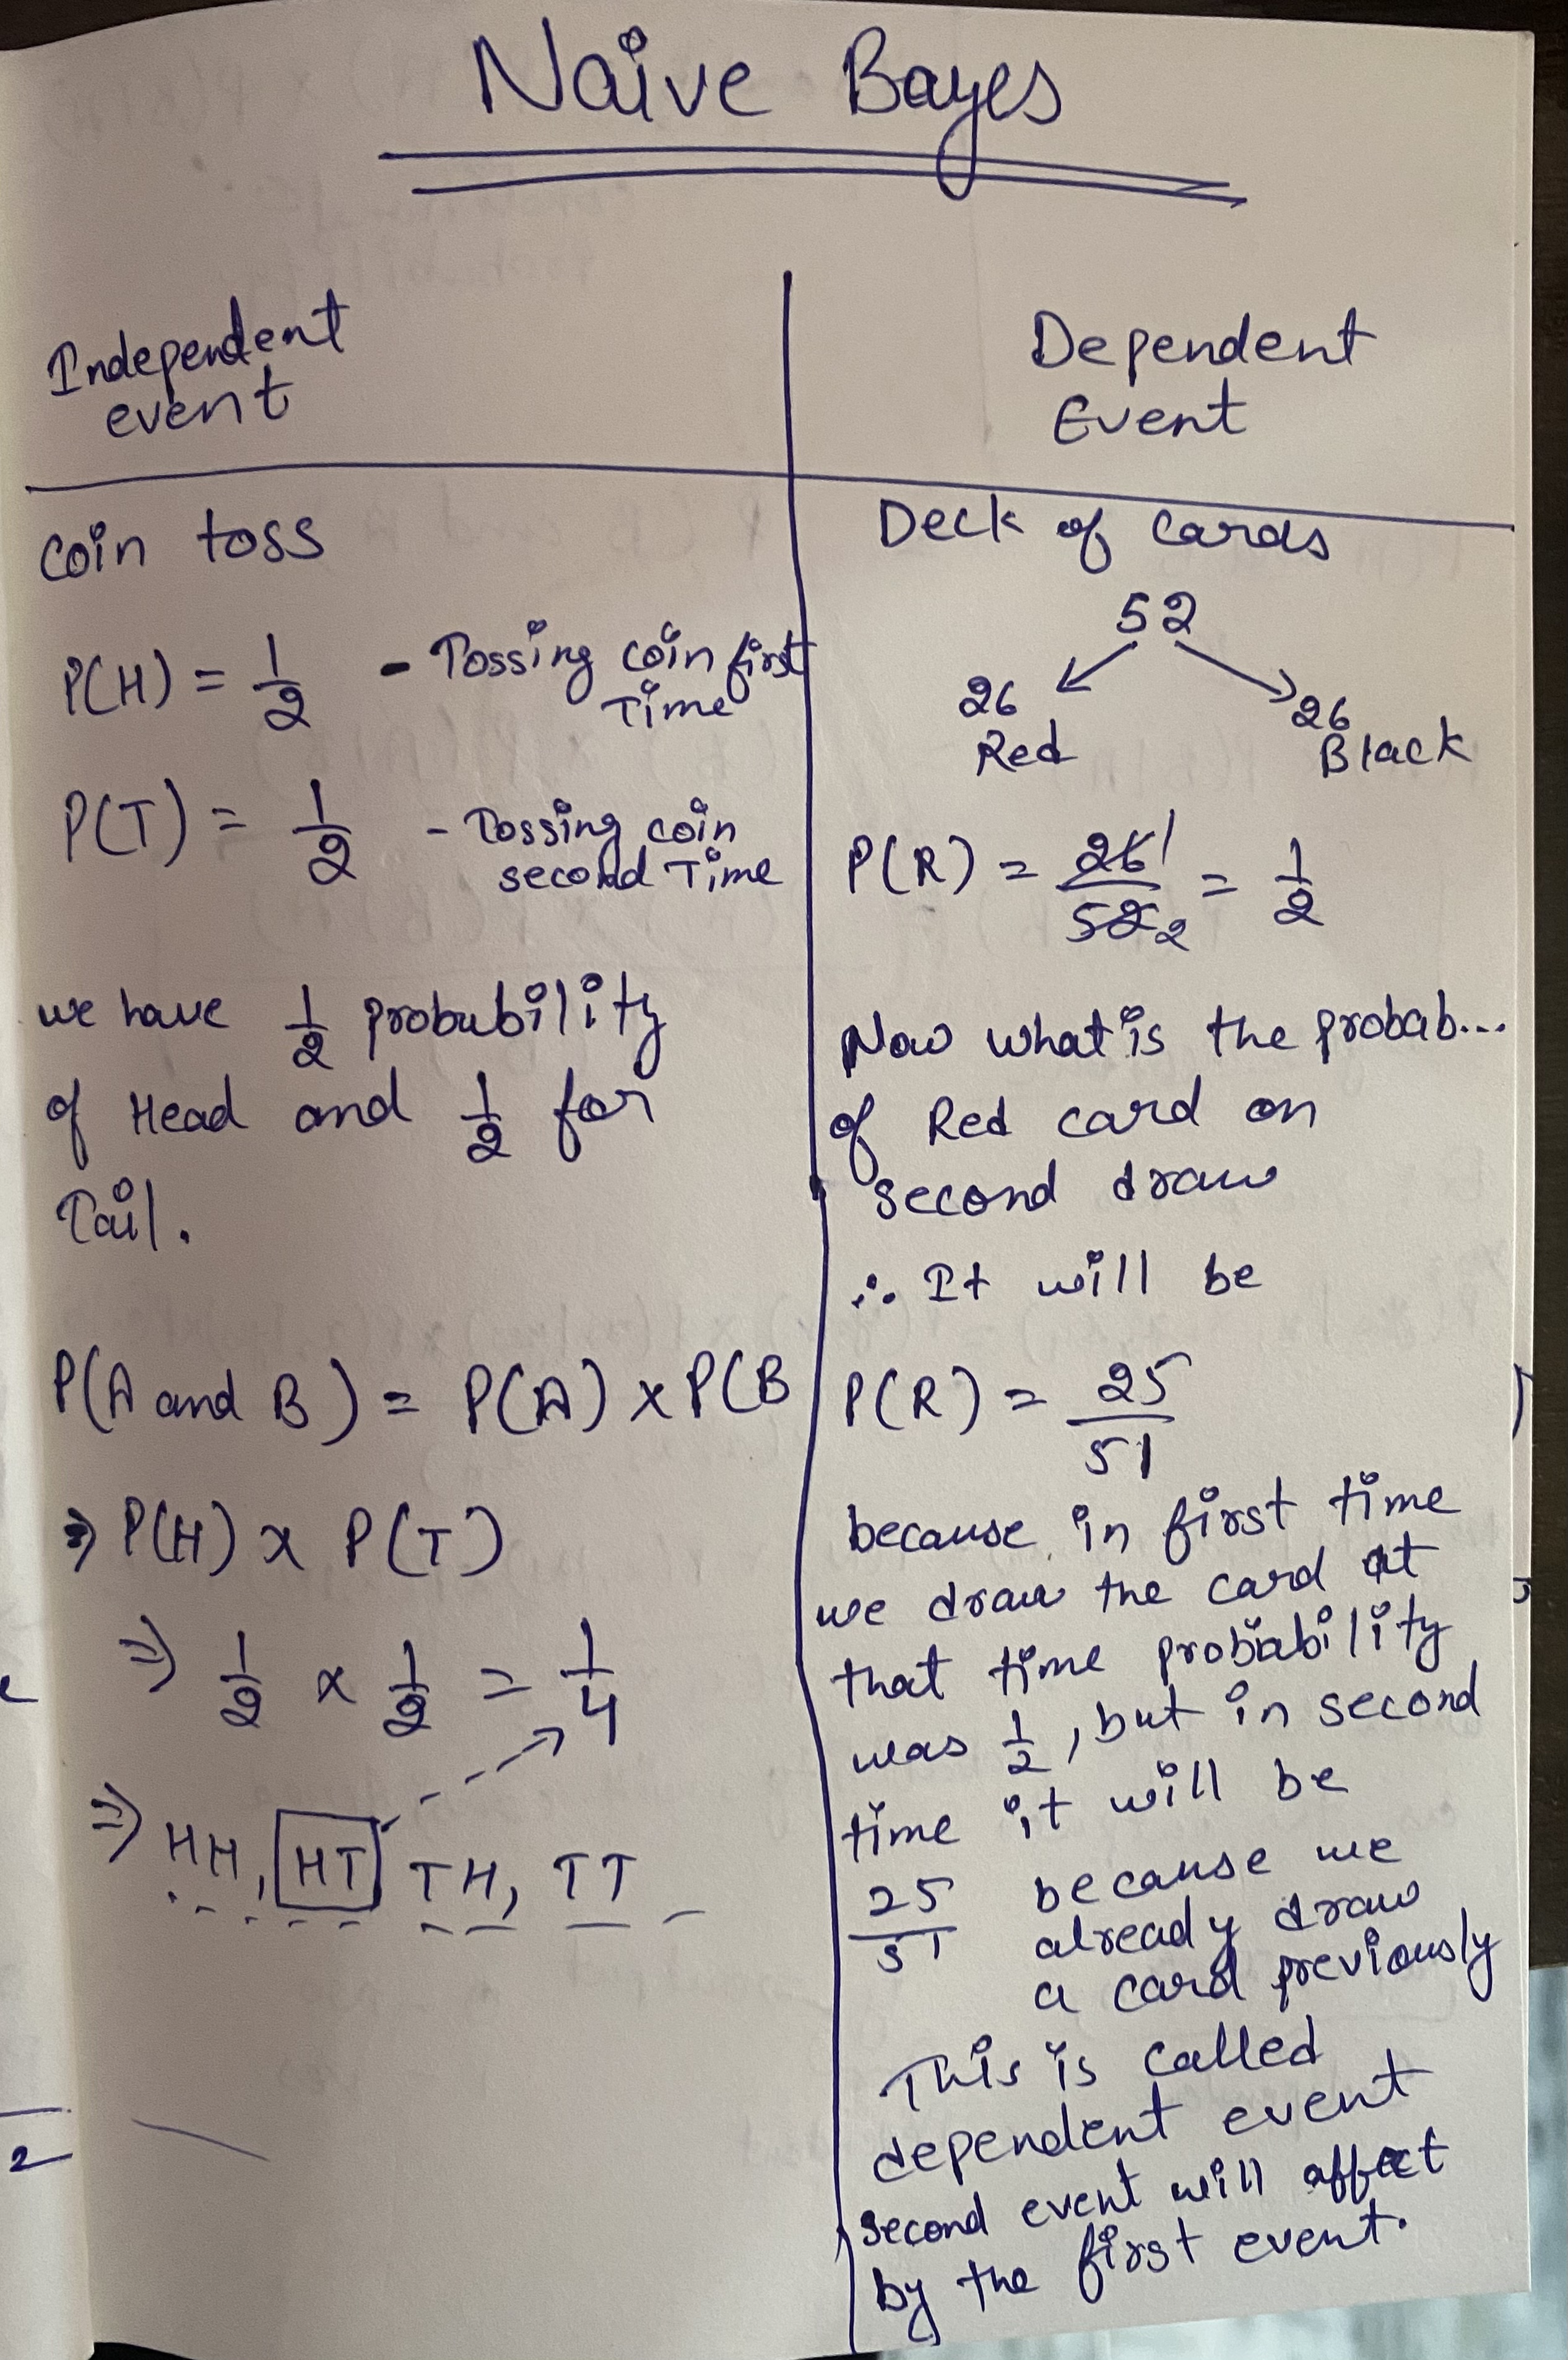
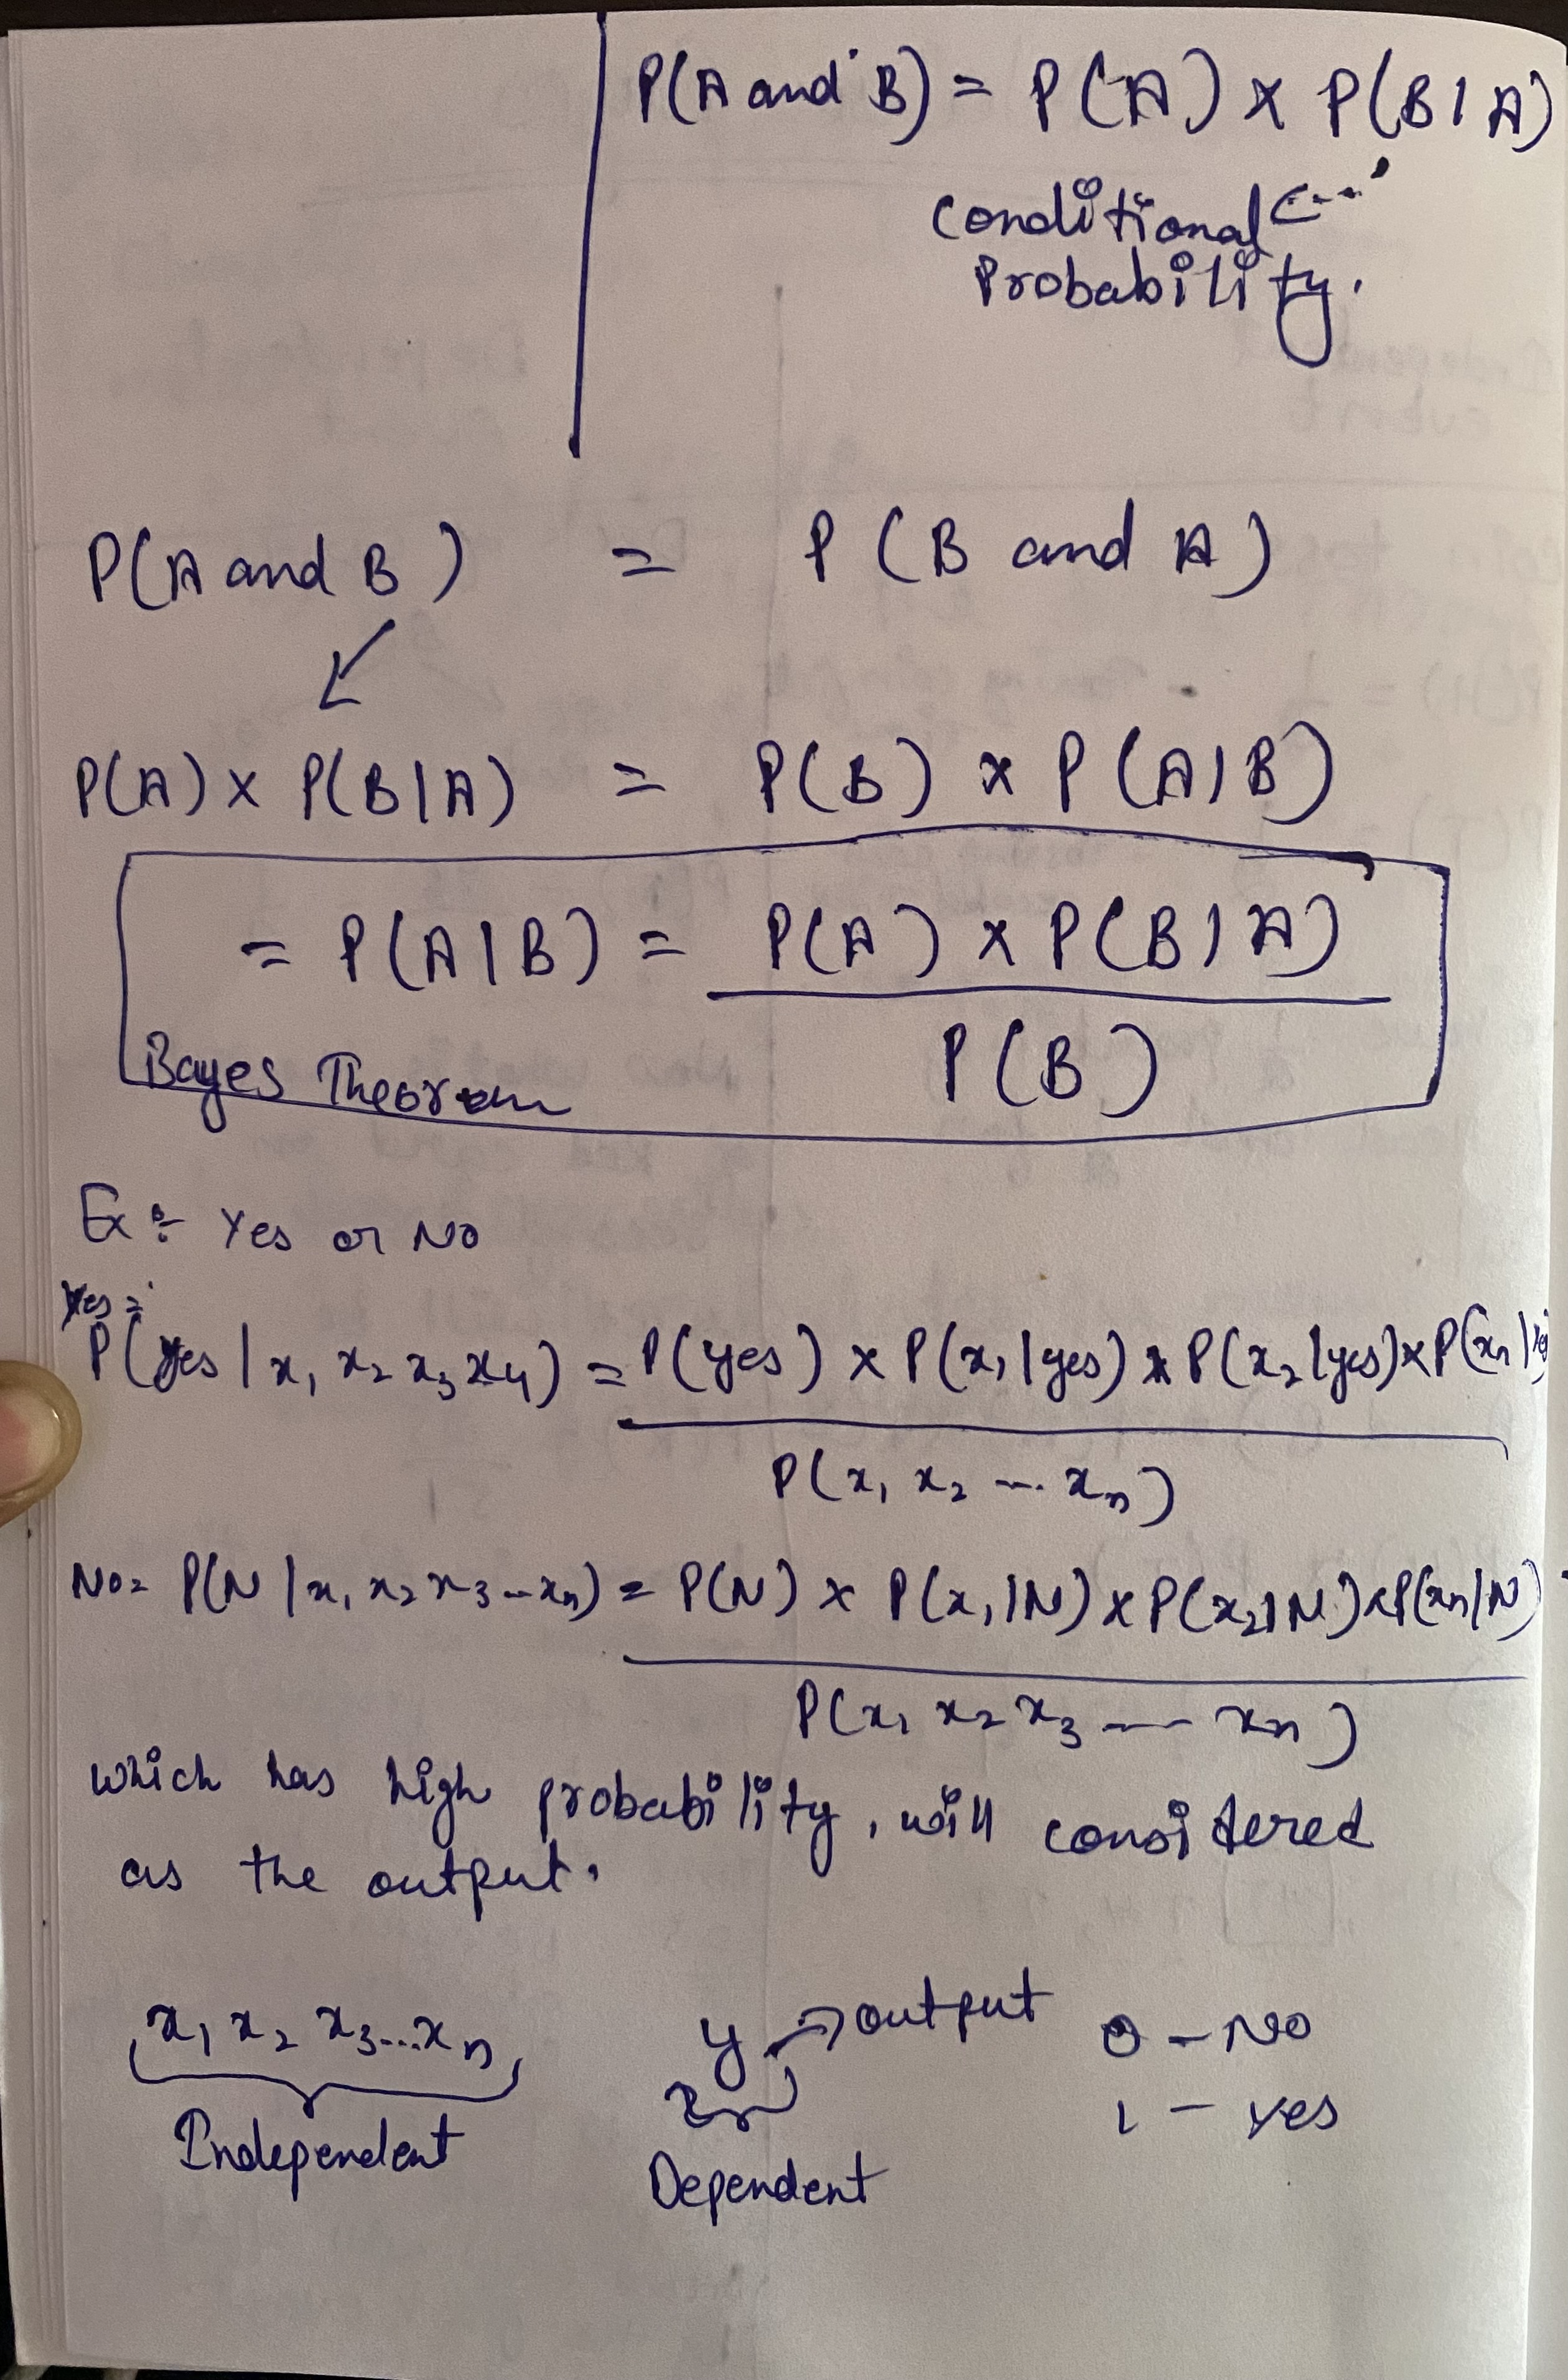

In [28]:

x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked']) 
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

y = df['Survived']
scale = StandardScaler()
x = scale.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [29]:
model = GaussianNB()
model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [30]:
y_pred = model.predict(x_test)

In [31]:
precision_score(y_test, y_pred)

0.782608695652174

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       111
           1       0.78      0.79      0.79        68

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



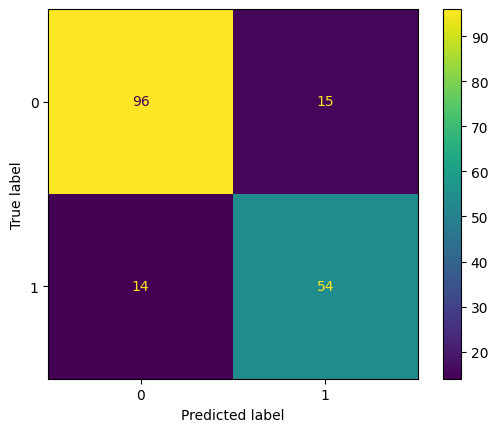

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
con_mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(con_mat).plot()

### There are some more Gause navie Byes model for different kind of problem and dataset.
1. Multinomial Naive Bayes - is one of the two classic naive Bayes variants used in text classification (where the data are typically represented as word vector counts, although tf-idf vectors are also known to work well in practice)

2. Complement Naive Bayes -  is particularly suited for imbalanced data sets. Specifically, CNB uses statistics from the complement of each class to compute the model’s weights.

3. Bernoulli Naive Bayes - for data that is distributed according to multivariate Bernoulli distributions; i.e., there may be multiple features but each one is assumed to be a binary-valued (Bernoulli, boolean) variable. Therefore, this class requires samples to be represented as binary-valued feature vectors

4. Categorical Naive Bayes - for categorically distributed data. It assumes that each feature, which is described by the index , has its own categorical distribution.
